# Data Preparation & Pipeline

### Item 1 Paragraph

The data aquisition process for this project mainly entiled gathering data from the movie lens dataset (32 million record version). The files were then downloaded and unpacked. To start, the movies and the ratings files were split up. The movies file became mov and only contains information on movies. The users file has a unique row for each user. Then the users file was supplemented with synthetic data to mimic their jobs, salary, and age. The ratings data table became rat and has ratings from all the users. Finally, another datatable was created that describes users watching history.

In [1]:
import pandas as pd


Create the first table, ratings

In [2]:
rat = pd.read_csv("C:/Users/thema/Downloads/ratings.csv")
rat

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858
...,...,...,...,...
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800


Create second table, users

In [3]:
#getting unique users
users = pd.DataFrame(rat['userId'].unique(), columns=['userId'])

The users table will consist of synthetic data for each user. This data will be created with random number generators

In [4]:
import numpy as np

# List of the 20 most common jobs in the US
# Referenced from https://www.indeed.com/career-advice/finding-a-job/common-jobs 
common_jobs = [
    "Cashier",
    "Food preparation worker",
    "Server",
    "Janitor",
    "Retail sales associate",
    "Laborer",
    "Customer service representative",
    "Office clerk",
    "Nursing assistant",
    "Administrative assistant",
    "Accounting clerk",
    "Maintenance technician",
    "Elementary school teacher",
    "General manager",
    "Accountant",
    "Truck driver",
    "Marketing manager",
    "Registered nurse",
    "Web developer",
    "Sales manager"
]

# Create a NumPy random generator
rng = np.random.default_rng()

# Function to generate random jobs using NumPy
def rand_job(size):
    indices = rng.integers(low=0, high=len(common_jobs), size=size)
    return [common_jobs[i] for i in indices]

# add a random job column to your users table
users['job'] = rand_job(len(users))

# Check the result
print(users.head())

   userId                     job
0       1                  Server
1       2        Accounting clerk
2       3        Accounting clerk
3       4                  Server
4       5  Retail sales associate


In [5]:
# age

# Create a NumPy random generator
rng = np.random.default_rng()

# Function to generate random ages between 8 and 92
def rand_age(size):
    return rng.integers(low=18, high=65, size=size)  # Working age Americans (65 is age of retirement)

# add a random age column to your users table
users['age'] = rand_age(len(users))

# Check the result
print(users.head())

   userId                     job  age
0       1                  Server   28
1       2        Accounting clerk   29
2       3        Accounting clerk   30
3       4                  Server   52
4       5  Retail sales associate   52


In [6]:
# Map each job to a typical average salary
# This data was generated with information from https://www.indeed.com/career-advice/finding-a-job/common-jobs 
job_salary_map = {
    "Cashier": 24193,
    "Food preparation worker": 31931,
    "Server": 32845,
    "Janitor": 39110,
    "Retail sales associate": 43169,
    "Laborer": 45580,
    "Customer service representative": 38964,
    "Office clerk": 36770,
    "Nursing assistant": 34172,
    "Administrative assistant": 40052,
    "Accounting clerk": 50618,
    "Maintenance technician": 49794,
    "Elementary school teacher": 49324,
    "General manager": 59777,
    "Accountant": 59606,
    "Truck driver": 74931,
    "Marketing manager": 70297,
    "Registered nurse": 70822,
    "Web developer": 77791,
    "Sales manager": 81041
}

# Create NumPy random generator
rng = np.random.default_rng()

def correlated_salary(jobs, sigma=0.3):
    """
    Generate salaries correlated with job type.
    Uses a log-normal distribution centered at the typical average.
    sigma controls spread of variation.
    """
    salaries = []
    for job in jobs:
        avg = job_salary_map.get(job, 40000)  # fallback
        # compute log-mean
        mu = np.log(avg)
        # generate a lognormal around avg
        s = rng.lognormal(mean=mu, sigma=sigma)
        salaries.append(round(s, 2))
    return salaries

# Assign correlated salaries
users['salary'] = correlated_salary(users['job'].tolist())

print(users[['userId','job','salary']].head())

   userId                     job    salary
0       1                  Server  43403.34
1       2        Accounting clerk  49065.99
2       3        Accounting clerk  43390.62
3       4                  Server  30056.40
4       5  Retail sales associate  63447.20


In [7]:
# peak at the data
users.head()

,userId,job,age,salary
0,1,Server,28,43403.34
1,2,Accounting clerk,29,49065.99
2,3,Accounting clerk,30,43390.62
3,4,Server,52,30056.40
4,5,Retail sales associate,52,63447.20


The third data table is all about movies

In [8]:
url = "C:/Users/thema/Downloads/movies.csv"
mov = pd.read_csv(url)
mov

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama


In [9]:
#cleaning and transformation of the dataset
# extract year
mov['year'] = mov['title'].str.extract(r'\((\d{4})\)$')

# convert to integer (optional)
mov['year'] = mov['year'].astype('Int64')

# remove year from title (optional)
mov['title'] = mov['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)

In [10]:
# one-hot encode genres
genres_dummies = mov['genres'].str.get_dummies(sep='|')

# join back to dataframe
mov = pd.concat([mov, genres_dummies], axis=1)

#drop genres column
mov = mov.drop(columns=['genres'])

In [11]:
# lets peak 
mov

,movieId,title,year,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story,1995,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji,1995,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men,1995,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale,1995,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II,1995,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87580,292731,The Monroy Affaire,2022,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
87581,292737,Shelter in Solitude,2023,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
87582,292753,Orca,2023,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
87583,292755,The Angry Breed,1968,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The fourth table is a calculated data table on users watch history

In [12]:
rng = np.random.default_rng()

# Only consider users who have watched at least one movie
users_with_ratings = rat['userId'].unique()

# Count movies watched per user
user_counts = rat.groupby('userId')['movieId'].count()
# Average rating per user
user_avg = rat.groupby('userId')['rating'].mean()

# Merge counts and averages into one table
watch_history = pd.DataFrame({
    'userId': user_counts.index,
    'num_movies_watched': user_counts.values,
    'avg_rating': user_avg.values
})

# Simulate total minutes watched (80–120 min per movie)
avg_movie_length = rng.integers(80, 121, size=len(watch_history))
watch_history['total_minutes_watched'] = (watch_history['num_movies_watched'] * avg_movie_length).astype(int)

In [13]:
# lets peak 
watch_history

,userId,num_movies_watched,avg_rating,total_minutes_watched
0,1,141,3.531915,11844
1,2,52,4.269231,6188
2,3,147,3.588435,12054
3,4,27,2.629630,2727
4,5,33,3.272727,3267
...,...,...,...,...
200943,200944,298,3.947987,30694
200944,200945,108,3.101852,12528
200945,200946,23,4.391304,2277
200946,200947,61,3.950820,5002


Finally, the fifth datatable is specifically movies that are on Netflix

In [14]:
net = pd.read_csv("C:/Users/thema/Downloads/netflix_titles.csv")
#only keep the title column as that is the only information that all other movies have
net = net["title"]
net.head()

0     Dick Johnson Is Dead
1            Blood & Water
2                Ganglands
3    Jailbirds New Orleans
4             Kota Factory
Name: title, dtype: object

In [15]:
net_mov = pd.merge(mov, net, how='inner', on='title')

In [16]:
net_mov.head()

,movieId,title,year,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,7,Sabrina,1995,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,10,GoldenEye,1995,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,13,Balto,1995,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,21,Get Shorty,1995,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,0
4,24,Powder,1995,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


To save all of these files, download them as parquet files

In [17]:
# Save all tables as Parquet files
users.to_parquet('data/users.parquet', index=False)
rat.to_parquet('data/rat.parquet', index=False)
mov.to_parquet('data/mov.parquet', index=False)
watch_history.to_parquet('data/watch_history.parquet', index=False)
net_mov.to_parquet('data/net_mov.parquet', index=False)

Load them into DuckDB

In [18]:
import duckdb
con = duckdb.connect(database='movies.duckdb', read_only=False)
con.execute("CREATE TABLE IF NOT EXISTS mov AS SELECT * FROM read_parquet('data/mov.parquet');")
con.execute("CREATE TABLE IF NOT EXISTS netmov AS SELECT * FROM read_parquet('data/net_mov.parquet');")
con.execute("CREATE TABLE IF NOT EXISTS rat AS SELECT * FROM read_parquet('data/rat.parquet');")
con.execute("CREATE TABLE IF NOT EXISTS users AS SELECT * FROM read_parquet('data/users.parquet');")
con.execute("CREATE TABLE IF NOT EXISTS history AS SELECT * FROM read_parquet('data/watch_history.parquet');")

con.close()


In [19]:
con.close()

Now moving on to querying and model building

Finding all ratings for movies that do appear on Netflix

In [20]:
con = duckdb.connect(database='movies.duckdb', read_only=False)

#creating the database that the model will be trained upon
net_df = con.execute("""
    SELECT 
        u.*, 
        r.rating, 
        m.*,
        h.num_movies_watched, h.total_minutes_watched
        FROM users u
    INNER JOIN history h ON h.userId = u.userId
    INNER JOIN rat r on r.userID = u.userId
    INNER JOIN mov m ON m.movieId = r.movieId
    LEFT JOIN netmov n ON n.movieId = m.movieId
    WHERE n.movieId IS NOT NULL;
""").fetchdf()

con.close()

Finding all ratings for movies that do not appear on Netflix. Limiting this to the first 4 million reviews for memory reasons

In [21]:
con = duckdb.connect(database='movies.duckdb', read_only=False)

#creating the database that the model will be tested upon
movs_df = con.execute("""
    SELECT 
        u.*, 
        r.rating, 
        m.*,
        h.num_movies_watched, h.total_minutes_watched
        FROM users u
    INNER JOIN history h ON h.userId = u.userId
    INNER JOIN rat r on r.userID = u.userId
    INNER JOIN mov m ON m.movieId = r.movieId
    LEFT JOIN netmov n ON n.movieId = m.movieId
    WHERE n.movieId IS NULL
    LIMIT 500000;
""").fetchdf()

con.close()

Test to ensure that there is no overlap with movies

In [22]:
#test

df_merged = movs_df.merge(net_df, on='movieId', how='inner')
df_merged.shape

(0, 59)

#### Data Cleaning


In [23]:
movs_df.head()

,userId,job,age,salary,rating,movieId,title,year,(no genres listed),Action,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,num_movies_watched,total_minutes_watched
0,6408,Marketing manager,27,165245.12,3.0,67923,"Fast & Furious (Fast and the Furious 4, The)",2009,0,1,...,0,0,0,0,0,1,0,0,794,81782
1,6408,Marketing manager,27,165245.12,3.0,68205,Crank: High Voltage,2009,0,1,...,0,0,0,0,0,0,0,0,794,81782
2,6408,Marketing manager,27,165245.12,3.0,68319,X-Men Origins: Wolverine,2009,0,1,...,0,0,0,0,1,1,0,0,794,81782
3,6408,Marketing manager,27,165245.12,4.5,68347,Sin Nombre,2009,0,0,...,0,0,0,0,0,1,0,0,794,81782
4,6408,Marketing manager,27,165245.12,3.5,68954,Up,2009,0,0,...,0,0,0,0,0,0,0,0,794,81782


In [24]:
#splitting into input and prediction data
y = movs_df["rating"]
X = movs_df.drop("rating", axis=1)

In [25]:
#getting rid of large categorical columns
X.drop(["title", "year"], axis=1, inplace=True)

In [26]:
#one hot encoding the job column
#one hot encode
dummies = pd.get_dummies(X["job"], prefix="job")
#make it numerical
dummies = dummies.astype(int)
#join the columns
X = X.join(dummies)
#drop the old columns
X.drop(columns=["job"], inplace=True)

In [27]:
#finally, drop the user and movie ID columns

X.drop(["movieId", "userId"], axis = 1, inplace=True)

In [28]:
X.head()

,age,salary,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,job_Maintenance technician,job_Marketing manager,job_Nursing assistant,job_Office clerk,job_Registered nurse,job_Retail sales associate,job_Sales manager,job_Server,job_Truck driver,job_Web developer
0,27,165245.12,0,1,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1,27,165245.12,0,1,0,0,0,1,1,0,...,0,1,0,0,0,0,0,0,0,0
2,27,165245.12,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,27,165245.12,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
4,27,165245.12,0,0,1,1,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0


#### Model Work

For this project, the netflix movie dataset will be split up into a training and testing dataset

In [29]:
#import needed packages
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [32]:
# split the data to obtain a training and testing set
X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
#Ridge Regression pipeline
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

In [34]:
#create the possible parameter dict
parameter_grid_ridge = {"ridge__alpha": [0.1, 1.0, 10, 100]}
#find best parameter
grid_search_ridge = GridSearchCV(ridge, parameter_grid_ridge)
grid_search_ridge.fit(X_train_ridge, y_train_ridge.values.ravel())
print(grid_search_ridge.best_params_)

{'ridge__alpha': 1.0}


In [35]:
#grab the optimal parameter
best_alpha = grid_search_ridge.best_params_["ridge__alpha"]

In [36]:
#ridge pipeline with the optimal parameter
improved_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha = best_alpha))
])

In [37]:
#fit the model with the optimal parameter
improved = improved_ridge.fit(X_train_ridge, y_train_ridge.values.ravel())

In [40]:
#make predictions
y_pred = improved_ridge.predict(X_test_ridge)

In [42]:
#score
r2 = r2_score(y_test_ridge, y_pred) # Score based on test set
print("R2 is equal to:", r2)
#score
MSE = mean_squared_error(y_test_ridge, y_pred) # Score based on test set
print("MSE is equal to: ", MSE)
#score
rmse = np.sqrt(MSE)
print("Ridge RMSE:", rmse)

R2 is equal to: 0.06566743239056883
MSE is equal to:  1.0473469974072325
Ridge RMSE: 1.0233997251354099


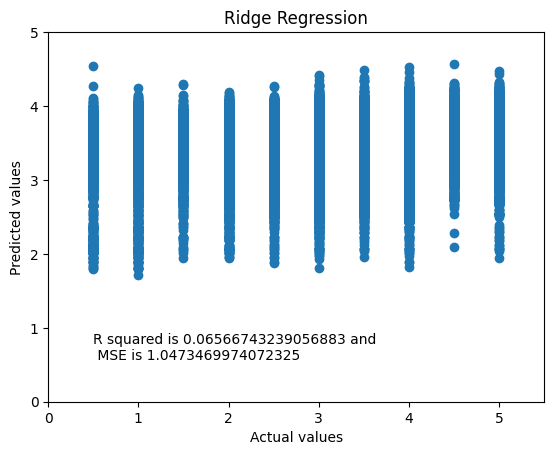

In [53]:
#plot the Ridge
plt.scatter(y_test_ridge, y_pred)
plt.xlim((0, 5.5))
plt.ylim((0, 5))
plt.title("Ridge Regression")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
#add in the performance metrics
plt.text(x = min(y_test_ridge), y = max(y_pred)-4, s = f"R squared is {r2} and \n MSE is {MSE}")
plt.show()

In [ ]:
X